In [1]:
# IN03: API vs MCP, Framework Selection, and Build vs Buy

In [2]:
# Problem statement:
# Imagine Walmart wants to build an AI Retail Assistant that will be used across thousands of stores.
# A store manager asks:
#     “Based on today’s actual weather and current market demand, what products should I stock more of today?”
# The AI assistant therefore needs to connect to external systems such as weather data and market-demand information, analyze them, and give a recommendation.

# But before Walmart builds this system at enterprise scale, the engineering team has to make 3 important architecture decisions:
# 1. How should the AI connect to tools and external systems?
#     REST APIs or Model Context Protocol (MCP)?
# 2. Which framework should we use to build the agent?
#     Plain Python or Langchain or Langgraph
# 3. Should Walmart build each component itself or buy/use an existing solution?

In [3]:
# The running Walmart use case
# The notebook assumes an AI assistant operating at approximately 4,700 stores and 50,000+ queries per day.
# For a Bengaluru store, the assistant receives a question like:
#     “Using today’s actual weather and current market-demand signals, recommend 3 product categories we should prioritize stocking today.”

# It retrieves live weather data from OpenWeatherMap and live demand signals through Tavily, then lets the LLM produce the recommendation.

# So the business problem is not just:
#     “Can an AI agent answer this question?”
# The bigger engineering question is:
#     “What architecture should Walmart choose so that this kind of AI assistant remains scalable, maintainable and manageable when thousands of stores and multiple AI agents start using it?”

In [4]:
# Load the libraries and keys needed for the full notebook.
# This cell also defines the store we will use in every example.
import os
import json
import time
import requests
from typing import TypedDict
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)

OPENAI_KEY  = os.getenv('OPENAI_API_KEY')
WEATHER_KEY = os.getenv('OPENWEATHERMAP_API_KEY')
TAVILY_KEY  = os.getenv('TAVILY_API_KEY')

client = OpenAI(api_key=OPENAI_KEY)

# Check whether all required API keys are present before we continue.
missing = [k for k, v in {
    'OPENAI_API_KEY':         OPENAI_KEY,
    'OPENWEATHERMAP_API_KEY': WEATHER_KEY,
    'TAVILY_API_KEY':         TAVILY_KEY,
}.items() if not v]

if missing:
    print(f'WARNING: Missing API keys: {missing}')
    print('Add them to your .env file before running this notebook.')
else:
    print('All required API keys loaded.')

# Fixed store context keeps every comparison in the notebook consistent.
STORE_ID   = 'WMT-2847'
STORE_CITY = 'Bengaluru'
print(f'Store context: {STORE_ID} | {STORE_CITY}, India')

All required API keys loaded.
Store context: WMT-2847 | Bengaluru, India


## The Decision Landscape

Every production AI system at Walmart scale requires three interlocking decisions made before any code is written:

1. **Protocol selection:** How should your AI agent communicate with external systems? REST API or Model Context Protocol (MCP)?
2. **Framework selection:** What orchestration layer do you build on? LangChain, LangGraph, or Python-only?
3. **Build vs Buy:** For each component, is it cheaper to build it or to buy a vendor solution?

Each decision compounds. A wrong protocol choice forces a framework rewrite downstream.

**The running scenario throughout this notebook:**

> *You are the AI engineer for the Walmart India Retail Assistant deployed at 4,700 stores with 50,000+ queries per day. The store manager at WMT-2847 in Bengaluru asks: "Based on today's actual conditions, what should we prioritise stocking today?"*

Every tool call in this notebook returns **live data** from real external APIs. The recommendation changes based on real weather and real market signals retrieved at runtime.

## Core API Functions

These two functions are the live data foundation used across all three sections.
Both make real HTTP calls to external services every time they are invoked.

In [5]:
# def fetch_weather(city: str, country_code: str = 'IN') -> dict: # fetch_weather("Bengaluru", "IN")
#     # Call the live OpenWeatherMap API for current weather.
#     url    = 'https://api.openweathermap.org/data/2.5/weather'
#     params = {'q': f'{city},{country_code}', 'appid': WEATHER_KEY, 'units': 'metric'} # units=metric gives temperature in Celsius, units=imperial gives temperature in Fahrenheit
#     resp   = requests.get(url, params=params, timeout=10)
#     resp.raise_for_status() # Raise an exception if the API call failed (e.g., invalid API key, city not found, etc.)
#     d = resp.json() # Parse the JSON response into a Python dictionary.
#     # For debugging, you can print the raw JSON response:
#     # print("=="*40)
#     # print("Raw weather API response:")
#     # print(json.dumps(d, indent=2))
#     # print("=="*40)
#     return {
#         'city':           d['name'],
#         'country':        d['sys']['country'],
#         'temperature_c':  round(d['main']['temp'], 1),
#         'feels_like_c':   round(d['main']['feels_like'], 1),
#         'humidity_pct':   d['main']['humidity'],
#         'condition':      d['weather'][0]['description'],
#         'condition_main': d['weather'][0]['main'],
#         'wind_speed_ms':  d['wind']['speed'],
#         'pressure_hpa':   d['main']['pressure'],
#     }

# # Calling the weather API for the store city to verify that it works.
# # data = fetch_weather(STORE_CITY) # fetch_weather("Bengaluru", "IN")
# # print(f"Weather in {data['city']}, {data['country']}: {data['temperature_c']}°C, {data['condition']} (feels like {data['feels_like_c']}°C, humidity {data['humidity_pct']}%)")

# data = fetch_weather("New York", "US")
# print(f"Weather in {data['city']}, {data['country']}: {data['temperature_c']}°C, {data['condition']} (feels like {data['feels_like_c']}°C, humidity {data['humidity_pct']}%)")

In [6]:
# def fetch_demand_trends(query: str, max_results: int = 3) -> dict:
#     # Call the live Tavily API for current market demand signals.
#     resp = requests.post(
#         'https://api.tavily.com/search',
#         json={
#             'api_key':        TAVILY_KEY,
#             'query':          query,
#             'max_results':    max_results,
#             'search_depth':   'basic',
#             'include_answer': True,
#         },
#         timeout=15,
#     )
#     resp.raise_for_status()
#     data = resp.json()
#     return {
#         'answer':  data.get('answer', ''),
#         'results': [
#             {'title': r['title'], 'content': r['content']}
#             for r in data.get('results', [])
#         ],
#     }

# resp = fetch_demand_trends("Bengaluru, India product demand trends")
# print(f"Demand trends answer: {resp['answer']}")

In [7]:
# These helper functions are the live data layer used everywhere below.
# One gets weather data and the other gets demand signals from search.
def fetch_weather(city: str, country_code: str = 'IN') -> dict:
    # Call the live OpenWeatherMap API for current weather.
    url    = 'https://api.openweathermap.org/data/2.5/weather'
    params = {'q': f'{city},{country_code}', 'appid': WEATHER_KEY, 'units': 'metric'}
    resp   = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    d = resp.json()
    return {
        'city':           d['name'],
        'country':        d['sys']['country'],
        'temperature_c':  round(d['main']['temp'], 1),
        'feels_like_c':   round(d['main']['feels_like'], 1),
        'humidity_pct':   d['main']['humidity'],
        'condition':      d['weather'][0]['description'],
        'condition_main': d['weather'][0]['main'],
        'wind_speed_ms':  d['wind']['speed'],
        'pressure_hpa':   d['main']['pressure'],
    }


def fetch_demand_trends(query: str, max_results: int = 3) -> dict:
    # Call the live Tavily API for current market demand signals.
    resp = requests.post(
        'https://api.tavily.com/search',
        json={
            'api_key':        TAVILY_KEY,
            'query':          query,
            'max_results':    max_results,
            'search_depth':   'basic',
            'include_answer': True,
        },
        timeout=15,
    )
    resp.raise_for_status()
    data = resp.json()
    return {
        'answer':  data.get('answer', ''),
        'results': [
            {'title': r['title'], 'content': r['content'][:350]}
            for r in data.get('results', [])
        ],
    }


# Quick live check so we know both external services are working.
print('Verifying live API connections...')
print()

live_weather = fetch_weather(STORE_CITY)
print(f'OpenWeatherMap -- {live_weather["city"]}, {live_weather["country"]}:')
print(f'  Temperature : {live_weather["temperature_c"]} C  (feels like {live_weather["feels_like_c"]} C)')
print(f'  Condition   : {live_weather["condition"]}')
print(f'  Humidity    : {live_weather["humidity_pct"]}%   Wind: {live_weather["wind_speed_ms"]} m/s')

print()
live_demand = fetch_demand_trends(f'retail grocery product demand {STORE_CITY} India')
print(f'Tavily Search -- query returned {len(live_demand["results"])} results:')
if live_demand['answer']:
    print(f'  Synthesised: {live_demand["answer"][:220]}...')
for r in live_demand['results'][:2]:
    print(f'  - {r["title"][:80]}')

Verifying live API connections...

OpenWeatherMap -- Bengaluru, IN:
  Temperature : 25.3 C  (feels like 25.8 C)
  Condition   : broken clouds
  Humidity    : 72%   Wind: 4.59 m/s

Tavily Search -- query returned 3 results:
  Synthesised: The sources indicate that Bengaluru's retail grocery market is growing, with a preference for product quality and freshness over price. The market is projected to grow significantly, with India's overall grocery market e...
  - Emerging Growth Market…Bangalore India
  - Bharat Grocery Market: India's Next Retail Growth Engine


## Section 1: REST API Integration -- Live External Services

In the REST pattern the developer manually writes a natural-language tool description and the AI uses that description to decide when and how to call the tool.

**Strengths:** Mature ecosystem, no new dependencies, works with any HTTP service.
**Weakness:** Tool schema lives in the developer's prompt. Schema drift and multi-agent reuse require copy-pasting descriptions across every agent that needs the tool.

The two tools below call **real external APIs** on every invocation:
- `get_store_weather` -- live call to OpenWeatherMap
- `search_demand_trends` -- live call to Tavily Search

In [8]:
# In the REST approach, the developer must explicitly tell the model:
# - what tools exist,
# - what each tool does,
# - what inputs each tool expects.

# This cell shows the REST approach.
# The developer writes the tool schema by hand and the model uses it.
# REST tool schema -- developer writes this by hand for each agent that needs it
REST_TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'get_store_weather',
            'description': (
                'Get real-time weather at a Walmart India store location. '
                'Use this to identify weather-driven demand: '
                'rain drives umbrella/raincoat/waterproof footwear sales, '
                'heat drives cold beverages/ice cream/sunscreen sales, '
                'cold drives hot beverages/heaters/blanket sales.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'city':         {'type': 'string', 'description': 'City where the Walmart store is located'},
                    'country_code': {'type': 'string', 'description': 'ISO country code (default IN for India)'},
                },
                'required': ['city'],
            },
        },
    },
    {
        'type': 'function',
        'function': {
            'name': 'search_demand_trends',
            'description': (
                'Search for real-time retail product demand trends and market signals using Tavily. '
                'Use this to identify high-demand product categories based on current market conditions.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string', 'description': 'Search query for demand or market signals'},
                    'max_results': {'type': 'integer', 'description': 'Number of results to return (1-5)'},
                },
                'required': ['query'],
            },
        },
    },
]


# This function acts like a dispatcher or router.
def execute_rest_tool(name: str, args: dict) -> str:
    # Route each REST tool call to the matching Python function.
    # Weather routing
    if name == 'get_store_weather':
        result = fetch_weather(args['city'], args.get('country_code', 'IN'))
    # Demand routing
    elif name == 'search_demand_trends':
        result = fetch_demand_trends(args['query'], args.get('max_results', 3))
    # Unknown tool routing
    else:
        result = {'error': f'Unknown tool: {name}'}
    # Convert result to JSON
    return json.dumps(result)


# It takes the Walmart manager's question and coordinates the entire process.
def walmart_rest_agent(query: str) -> dict:
    # Run a full REST-style agent loop with live tool calls.
    start    = time.time()
    messages = [
        {
            'role': 'system',
            'content': (
                f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                'Use available tools to retrieve live data before making recommendations. '
                'Base your answer entirely on the real data returned by the tools.'
            ),
        },
        {'role': 'user', 'content': query},
    ]

    tools_called = []
    total_in = total_out = 0

    # Agent loop
    # Keep calling the model until it stops asking for tools.
    for _ in range(6): # The model is allowed up to 6 rounds.
        resp = client.chat.completions.create(
            model='gpt-4o', messages=messages, tools=REST_TOOLS,
            tool_choice='auto', temperature=0, max_tokens=500,
        )
        total_in  += resp.usage.prompt_tokens
        total_out += resp.usage.completion_tokens
        msg = resp.choices[0].message

        if not msg.tool_calls:
            final_answer = msg.content.strip()
            break

        messages.append(msg)
        for tc in msg.tool_calls:
            args   = json.loads(tc.function.arguments)
            result = execute_rest_tool(tc.function.name, args)
            tools_called.append({'tool': tc.function.name, 'args': args})
            messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': result})

    latency = time.time() - start
    cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
    return {
        'answer':       final_answer,
        'tools_called': tools_called,
        'latency_sec':  round(latency, 2),
        'cost_usd':     round(cost, 6),
        'tokens_in':    total_in,
        'tokens_out':   total_out,
        'protocol':     'REST',
    }

In [9]:
# Step 1 → ask for weather
# Step 2 → receive weather
# Step 3 → ask for demand trends
# Step 4 → receive demand trends
# Step 5 → generate recommendation
# The 6 prevents an accidental infinite loop.

In [10]:
# Ask the REST agent the main Walmart store question and inspect the result.
STORE_QUERY = (
    f'I am the store manager at {STORE_ID} in {STORE_CITY}. '
    "Based on today's actual weather conditions and current market demand signals, "
    'give me 3 specific product categories I should prioritise stocking today. '
    'For each category, explain why the live data supports this recommendation.'
)

print(f'Query: {STORE_QUERY}')
print()

rest_result = walmart_rest_agent(STORE_QUERY)

# Show which tools were used before we read the final answer.
print('Tools called by the REST agent:')
for t in rest_result['tools_called']:
    print(f'  {t["tool"]}({json.dumps(t["args"])})')

print()
print('REST Agent Answer (based on live data):')
print('-' * 70)
print(rest_result['answer'])
print('-' * 70)
print(f'Latency : {rest_result["latency_sec"]}s')
print(f'Cost    : ${rest_result["cost_usd"]}')
print(f'Protocol: REST (hand-written tool schema)')

Query: I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation.

Tools called by the REST agent:
  get_store_weather({"city": "Bengaluru", "country_code": "IN"})
  search_demand_trends({"query": "Bengaluru", "max_results": 3})

REST Agent Answer (based on live data):
----------------------------------------------------------------------
Based on today's weather conditions and current market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking at the store:

1. **Cold Beverages and Ice Cream:**
   - **Weather Justification:** The current temperature in Bengaluru is 25.3°C with a "feels like" temperature of 25.8°C and 72% humidity. Although it's cloudy, the temperature is relatively warm, which can drive demand for cold bev

## Section 2: Model Context Protocol (MCP) -- Real FastMCP Server

MCP (Anthropic, 2024) separates tool definition from tool calling.
The MCP server owns the schema. Any MCP-compatible AI client connects, discovers tools automatically, and calls them -- without the developer writing a single word of tool description.

**Architecture:**
```
AI Host (GPT-4o-mini)  <-->  MCP Client (test_client)  <-->  FastMCP Server  <-->  Live External APIs
```

**What changes vs REST:**
- Tool descriptions live on the **server**, not in developer prompts
- Schema is **machine-readable** JSON -- no natural language required
- Any number of AI clients can point at the same server without duplicating schema
- The server handles versioning; clients auto-discover changes on reconnect

**What stays the same:**
- Underlying HTTP calls to OpenWeatherMap and Tavily are identical
- OpenAI token cost per call is the same
- MCP adds a schema-fetch round-trip on first connection (~5ms)

The FastMCP server below uses real API calls inside every registered tool.

In [11]:
# REST API approach: what is the problem?
# Weather → OpenWeatherMap
# Demand trends → Tavily

# With REST, the developer manually writes something like:
# REST_TOOLS = [
#    get_store_weather description + parameters,
#    search_demand_trends description + parameters
# ]
# That works perfectly when you have 1 agent and 2 tools.

# The problem appears when Walmart has:
#     - 50 different AI agents
#     - 100 different enterprise tools
#     - inventory API
#     - pricing API
#     - weather API
#     - supplier API
#     - SAP
#     - warehouse system
#     - order management system
#     - customer-service system
# Now every agent may need its own manually maintained tool definitions.

# For example, suppose the Inventory API changes from:
#     get_inventory(store_id)
# to:
#     get_inventory(store_id, sku, warehouse_id)
# With the traditional approach, you may have to find every AI application where that tool description/schema was copied and update it.

# That creates problems such as duplication, inconsistent schemas, maintenance effort and schema drift.


# Why MCP?
# MCP tries to move the definition of the capability away from every individual agent and put it behind a standard interface.

# MCP is an open standard for connecting AI applications to external tools and data.

# So instead of every Walmart AI application manually defining:
#     Inventory Tool
#     Weather Tool
#     Pricing Tool
#     Supplier Tool
# an MCP server can expose those capabilities in a standardized way.

In [12]:
# MCP approach
# Instead:
#                  Walmart Inventory MCP Server
#                          ↓
#                  get_inventory()
#                  check_stock()
#                  reorder_item()

#                     ↑      ↑      ↑
#                     |      |      |
#              Store Agent Inventory Agent Supply Agent

# The MCP server publishes the available capabilities.
# The clients can discover those tools rather than every developer manually recreating their schemas.
# That is one of the main architectural benefits.

In [13]:
# The 3 important MCP pieces: MCP Host, Client and Server.
# USER
#  ↓
# MCP HOST
#  ↓
# LLM
#  ↓
# MCP CLIENT
#  ↓
# MCP SERVER
#  ↓
# Actual system/API/database

# MCP Host:
# The Host is the AI application that the user is actually using.
# Examples could include an IDE, desktop AI application, or your own Walmart AI application. Official MCP documentation describes the host as the application the user interacts with. MCP Python SDK
# In our example:
#     Walmart Store Assistant
# is the MCP Host.


# MCP Client:
# Inside the Host is an MCP Client.
# Its job is to communicate with an MCP server using the MCP protocol.
# The client can essentially ask:
#     "What capabilities do you provide?"
# The server might respond:
#     get_store_weather
#     search_demand_trends
#     get_inventory
# The client then makes those capabilities available to the AI application.
# Official MCP SDK documentation describes the client as the component responsible for establishing and managing connections with MCP servers.


# MCP Server:
# This is probably the most important concept.
# An MCP Server exposes capabilities to AI applications in a standardized way.
# For our Walmart example we might create:
#     Retail MCP Server
# which exposes:
#     get_store_weather
#     search_demand_trends
#     get_inventory
#     get_supplier_status


In [14]:
# Complete Walmart example
# Suppose the manager asks:
#     "Based on today's weather and market demand, which 3 products should I prioritize?"

# The architecture could work like this:

# Store Manager
#      ↓
# Walmart AI Assistant
#      ↓
#    HOST
#      ↓
#     LLM
#      ↓
#  MCP CLIENT
#      ↓
#  Retail MCP SERVER
#      ↓
#  ┌─────────────┬─────────────┐
#  ↓                           ↓
# Weather API                Tavily
#  ↓                           ↓
# 23°C, rain              Demand signals
#  └─────────────┬─────────────┘
#                ↓
#               LLM
#                ↓
# Recommendation:
# 1. Umbrellas
# 2. Raincoats
# 3. Waterproof footwear

# REST works well for calling APIs, but when many AI agents need many tools, manually defining and maintaining those tool integrations becomes difficult. MCP provides a standardized, reusable way for AI applications to discover and use those capabilities.

In [15]:
# This cell sets up the FastMCP server and registers its tools.
# The main idea is that tool definitions live on the server side.
MCP_AVAILABLE = False

try:
    import inspect # inspect lets Python examine functions programmatically.
    # def get_store_weather(city: str, country_code: str = 'IN'): ==> inspect can discover:
     #     - function name
     #     - parameter names and types
     # from mcp.server.fastmcp import FastMCP
    from mcp.server.mcpserver import MCPServer

    # This helps async-friendly packages behave inside Jupyter.
    try:
        import nest_asyncio # Jupyter Notebook already runs an asynchronous event loop. Some MCP/network libraries also use async operations. This can sometimes create errors like: “Event loop is already running.” nest_asyncio.apply() allows these async operations to work more smoothly inside Jupyter.
        nest_asyncio.apply()
    except ImportError:
        pass

    # walmart_mcp = FastMCP(
    #     'walmart-store-ops',
    #     instructions=(
    #         'Walmart India Store Operations MCP Server. '
    #         'Exposes real-time weather intelligence and market demand signals '
    #         'for store management decisions at WMT stores across India.'
    #     ),
    # )

    walmart_mcp = MCPServer(
        'walmart-store-ops',
        instructions=(
            'Walmart India Store Operations MCP Server. '
            'Exposes real-time weather intelligence and market demand signals '
            'for store management decisions at WMT stores across India.'
        ),
    )

    @walmart_mcp.tool()
    def get_store_weather(city: str, country_code: str = 'IN') -> dict:
        """Get current weather at a Walmart India store location for demand planning."""
        return fetch_weather(city, country_code)

    @walmart_mcp.tool()
    def search_demand_trends(query: str, max_results: int = 3) -> dict:
        """Search live retail demand trends and market signals for store planning."""
        return fetch_demand_trends(query, max_results)

    @walmart_mcp.tool()
    def get_store_info(store_id: str) -> dict:
        """Retrieve operational metadata for a Walmart India store."""
        registry = {
            'WMT-2847': {'location': 'Bengaluru, Karnataka', 'format': 'Supercenter',
                         'departments': 32, 'daily_queries': 1200, 'region': 'South India'},
            'WMT-1023': {'location': 'Mumbai, Maharashtra',  'format': 'Supercenter',
                         'departments': 28, 'daily_queries': 1800, 'region': 'West India'},
            'WMT-0511': {'location': 'Delhi NCR',            'format': 'Supercenter',
                         'departments': 35, 'daily_queries': 2100, 'region': 'North India'},
            'WMT-3302': {'location': 'Hyderabad, Telangana', 'format': 'Neighborhood Market',
                         'departments': 18, 'daily_queries':  620, 'region': 'South India'},
        }
        return registry.get(store_id, {'error': f'Store {store_id} not found in registry'})

    def _annotation_to_json_type(annotation) -> str:
        # Convert Python type hints into simple JSON schema types.
        return {
            str: 'string',
            int: 'integer',
            float: 'number',
            bool: 'boolean',
            dict: 'object',
            list: 'array',
        }.get(annotation, 'string')

    def _build_mcp_tool_entry(func) -> dict:
        # Build a small machine-readable schema for each MCP tool.
        sig = inspect.signature(func) # get_store_weather(city: str, country_code: str = 'IN')
        properties = {} # properties will store all input parameters.
        required = [] # required will store parameters that must be provided.

        for param_name, param in sig.parameters.items():
            if param.kind not in (inspect.Parameter.POSITIONAL_OR_KEYWORD, inspect.Parameter.KEYWORD_ONLY):
                continue

            prop = {'type': _annotation_to_json_type(param.annotation)}
            if param.default is not inspect._empty:
                prop['default'] = param.default
            else:
                required.append(param_name)
            properties[param_name] = prop

        return {
            'name': func.__name__,
            'description': inspect.getdoc(func) or '',
            'inputSchema': {
                'type': 'object',
                'properties': properties,
                'required': required,
            },
            'handler': func,
        }

    # Keep the registered MCP tools in one place for easy lookup below.
    MCP_TOOL_REGISTRY = {
        tool['name']: tool
        for tool in [
            _build_mcp_tool_entry(get_store_weather),
            _build_mcp_tool_entry(search_demand_trends),
            _build_mcp_tool_entry(get_store_info),
        ]
    }

    def call_mcp_tool(name: str, args: dict) -> dict:
        # Run an MCP tool by name using the saved registry entry.
        return MCP_TOOL_REGISTRY[name]['handler'](**args)

    MCP_AVAILABLE = True
    print(f'FastMCP server created: {walmart_mcp.name}')
    print()
    print('Tools registered on the MCP server:')
    print('  - get_store_weather    (live data: OpenWeatherMap API)')
    print('  - search_demand_trends (live data: Tavily Search API)')
    print('  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)')
    print()
    print('Key difference from REST: tool descriptions live here on the server,')
    print('not in the developer\'s agent code. Any MCP client discovers them automatically.')

except ImportError as e:
    print(f'mcp package not installed: {e}')
    print('Install: pip install mcp --break-system-packages')
    print()
    print('The REST section above is fully functional without this package.')
    print('FastMCP cells below will be skipped gracefully.')

FastMCP server created: walmart-store-ops

Tools registered on the MCP server:
  - get_store_weather    (live data: OpenWeatherMap API)
  - search_demand_trends (live data: Tavily Search API)
  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)

Key difference from REST: tool descriptions live here on the server,
not in the developer's agent code. Any MCP client discovers them automatically.


In [16]:
# Now combine MCP tool schemas, MCP tool execution, and the LLM in one loop.
# This mirrors the REST agent flow, but the tool schema comes from the server side.
# Step 3: Full MCP Agent -- schema from server registry, tool execution from MCP server definitions

if MCP_AVAILABLE:
    def walmart_mcp_agent(query: str) -> dict:
        # Run a full MCP-style agent loop using the server-owned schema.
        start = time.time()

        openai_tools = [
            {
                'type': 'function',
                'function': {
                    'name':        t['name'],
                    'description': t['description'],
                    'parameters':  t['inputSchema'],
                },
            }
            for t in MCP_TOOL_REGISTRY.values()
        ]

        messages = [
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    'Tools are provided by the Walmart MCP server. '
                    'Use all relevant tools to give a complete, data-driven recommendation.'
                ),
            },
            {'role': 'user', 'content': query},
        ]

        tools_called = []
        total_in = total_out = 0
        final_answer = ''

        # Keep going until the model stops asking for tool calls.
        for _ in range(6):
            resp = client.chat.completions.create(
                model='gpt-4o-mini', messages=messages, tools=openai_tools,
                tool_choice='auto', temperature=0, max_tokens=500,
            )
            total_in  += resp.usage.prompt_tokens
            total_out += resp.usage.completion_tokens
            msg = resp.choices[0].message

            if not msg.tool_calls:
                final_answer = msg.content.strip()
                break

            messages.append(msg)

            for tc in msg.tool_calls:
                args   = json.loads(tc.function.arguments)
                result = call_mcp_tool(tc.function.name, args)
                tools_called.append({'tool': tc.function.name, 'args': args})
                messages.append({
                    'role':         'tool',
                    'tool_call_id': tc.id,
                    'content':      json.dumps(result),
                })

        latency = time.time() - start
        cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
        return {
            'answer':       final_answer,
            'tools_called': tools_called,
            'latency_sec':  round(latency, 2),
            'cost_usd':     round(cost, 6),
            'tokens_in':    total_in,
            'tokens_out':   total_out,
            'protocol':     'MCP',
        }

    mcp_result = walmart_mcp_agent(STORE_QUERY)

    print('Tools called via MCP protocol:')
    for t in mcp_result['tools_called']:
        print(f'  {t["tool"]}({json.dumps(t["args"])})')
    print()
    print('MCP Agent Answer (based on live data):')
    print('-' * 70)
    print(mcp_result['answer'])
    print('-' * 70)
    print(f'Latency : {mcp_result["latency_sec"]}s')
    print(f'Cost    : ${mcp_result["cost_usd"]}')
    print(f'Protocol: MCP (schema auto-discovered from FastMCP server)')

else:
    mcp_result = {**rest_result, 'protocol': 'MCP (fallback -- install mcp package)'}
    print('mcp package not installed. Showing REST result as reference.')
    print(f'Answer: {mcp_result["answer"][:300]}...')

[10/02/26 23:44:29] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=60418;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=385434;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[10/02/26 23:44:34] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=84827;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=436486;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[10/02/26 23:44:38] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=616618;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=835485;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[10/02/26 23:44:41] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=402612;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=692324;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[10/02/26 23:44:49] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=481604;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=645505;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Tools called via MCP protocol:
  get_store_weather({"city": "Bengaluru"})
  search_demand_trends({"query": "Bengaluru", "max_results": 3})
  search_demand_trends({"query": "grocery", "max_results": 3})
  search_demand_trends({"query": "beverages", "max_results": 3})
  search_demand_trends({"query": "snacks", "max_results": 3})

MCP Agent Answer (based on live data):
----------------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

### 1. **Beverages**
- **Weather Context**: The current temperature in Bengaluru is around 25.3°C with a humidity level of 72%. This warm and humid weather often leads to increased demand for refreshing beverages, both alcoholic and non-alcoholic.
- **Market Demand**: There is a consistent interest in a variety of beverages, including soft drinks, energy drinks, and bottled water. The demand for

## Section 3: Framework Selection -- LangChain vs LangGraph vs Python-only

Framework selection is a TCO (Total Cost of Ownership) decision, not a features decision.
Every framework adds capabilities and adds cost: dependency risk, debugging complexity, version lock, and team learning curve.

All three implementations below use the **same real live data** (OpenWeatherMap + Tavily).
The difference is in how each framework manages state, control flow, and observability.

In [17]:
# This version uses plain Python only: no tool framework, no graph, just direct calls.
# It is the simplest option, but the developer must control every step manually.
def python_only_agent(query: str) -> dict: # "I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation."
    # Python-only: full control, minimum abstraction.
    # Developer manually fetches data before the LLM call -- no dynamic tool calling.
    start = time.time()

    weather = fetch_weather(STORE_CITY)
    demand  = fetch_demand_trends(f'retail product demand {STORE_CITY} India', max_results=2)

    context = (
        f'Live weather for {STORE_CITY}: {json.dumps(weather)}. '
        f'Market demand signals: {demand["answer"]}'
    ) # concatenate live data into a single context string for the LLM.

    resp = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    f'Current live data: {context}'
                ),
            },
            {'role': 'user', 'content': query},
        ],
        temperature=0, max_tokens=400,
    )

    latency = time.time() - start
    ti, to  = resp.usage.prompt_tokens, resp.usage.completion_tokens
    return {
        'answer':      resp.choices[0].message.content.strip(),
        'latency_sec': round(latency, 2),
        'cost_usd':    round((ti * 0.15 + to * 0.60) / 1_000_000, 6),
        'framework':   'Python-only',
        'data_fetch':  'Manual pre-fetch (LLM cannot request more data dynamically)',
        'loc_approx':  30,
    }

py_result = python_only_agent(STORE_QUERY) # "I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation."
print('Python-only Agent Answer:')
print('-' * 60)
print(py_result['answer'])
print('-' * 60)
print(f'Latency: {py_result["latency_sec"]}s | Framework: Python-only')
print(f'Note   : {py_result["data_fetch"]}')

[10/02/26 23:44:55] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=270034;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=983556;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Python-only Agent Answer:
------------------------------------------------------------
Based on today's weather conditions and current market demand signals, here are three specific product categories you should prioritize stocking at WMT-2847 in Bengaluru:

1. **Rain Gear and Accessories:**
   - **Reasoning:** The current weather condition in Bengaluru is "broken clouds" with a relatively high humidity of 72%. This suggests a possibility of rain or at least a damp environment. Stocking rain gear such as umbrellas, raincoats, and waterproof footwear would cater to customers who might be preparing for unexpected showers.

2. **Air Purifiers and Humidifiers:**
   - **Reasoning:** With a humidity level of 72% and the presence of "broken clouds," the air quality might be a concern for some customers, especially those sensitive to humidity and potential pollutants. Air purifiers can help improve indoor air quality, while humidifiers can maintain comfortable humidity levels indoors, making t

In [18]:
STORE_QUERY

"I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation."

In [19]:
# %pip install langchain langchain-openai -q

In [20]:
# This version uses LangChain to manage tools and the agent loop for us.
# It reduces boilerplate, but adds another abstraction layer to learn and debug.
LC_AVAILABLE = False
lc_latency   = None

try:
    from langchain_openai import ChatOpenAI # LLM / Brain
    from langchain_core.prompts import ChatPromptTemplate # Prompt/Ears
    from langchain_core.tools import tool # Hands
    from langchain.agents import create_tool_calling_agent, AgentExecutor
    # create_tool_calling_agent - Combining LLM+Prompt+Tools
    # AgentExecutor - Running everything

    @tool
    def lc_get_weather(city: str) -> str:
        """Get real-time weather at a Walmart India store location for demand planning."""
        return json.dumps(fetch_weather(city))

    @tool
    def lc_search_trends(query: str) -> str:
        """Search for real-time retail demand trends and market signals using Tavily."""
        return json.dumps(fetch_demand_trends(query, max_results=2))

    lc_llm   = ChatOpenAI(model='gpt-4o', temperature=0)
    lc_tools = [lc_get_weather, lc_search_trends]

    lc_prompt = ChatPromptTemplate.from_messages([
        ('system',
         f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
         'Use tools to retrieve live data before making recommendations.'),
        ('human', '{input}'),
        ('placeholder', '{agent_scratchpad}'),
    ])

    lc_agent    = create_tool_calling_agent(lc_llm, lc_tools, lc_prompt)
    lc_executor = AgentExecutor(agent=lc_agent, tools=lc_tools, verbose=True, max_iterations=6)

    start       = time.time()
    lc_response = lc_executor.invoke({'input': STORE_QUERY})
    # lc_response = lc_executor.invoke({'input': "What is the current date and time in India?"})
    lc_latency  = time.time() - start

    print('LangChain Agent Answer (real tools via LCEL + AgentExecutor):')
    print('-' * 60)
    print(lc_response['output'][:450])
    print('-' * 60)
    print(f'Latency: {lc_latency:.2f}s | Framework: LangChain')
    LC_AVAILABLE = True

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install: pip install langchain langchain-openai --break-system-packages')

LangChain not installed: No module named 'langchain_core.memory'
Install: pip install langchain langchain-openai --break-system-packages


In [21]:
# This version uses LangChain to manage tools and the agent loop for us.
# It reduces boilerplate, but adds another abstraction layer to learn and debug.
LC_AVAILABLE = False
lc_latency   = None
import time

try:
    from langchain_openai import ChatOpenAI # Brain - LLM
    from langchain_core.prompts import ChatPromptTemplate # Mouth - prompt template
    from langchain_core.tools import tool # Hands - Tools
    from langchain.agents import create_tool_calling_agent, AgentExecutor
    # create_tool_calling_agent = Combine (LLM + Tools + PromptTemplate)

    @tool
    def lc_get_weather(city: str) -> str:
        """Get real-time weather at a Walmart India store location for demand planning."""
        return json.dumps(fetch_weather(city))

    @tool
    def lc_search_trends(query: str) -> str:
        """Search for real-time retail demand trends and market signals using Tavily."""
        return json.dumps(fetch_demand_trends(query, max_results=2))

    @tool
    def get_current_utc_date_and_time() -> str:
        """Get the current UTC date and time."""
        return json.dumps({'utc_datetime': time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime())})

    lc_llm   = ChatOpenAI(model='gpt-4o', temperature=0)
    # lc_tools = [lc_get_weather, lc_search_trends]
    lc_tools = [lc_get_weather, lc_search_trends, get_current_utc_date_and_time]

    lc_prompt = ChatPromptTemplate.from_messages([
        ('system',
         f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
         'Use tools to retrieve live data before making recommendations.'),
        ('human', '{input}'),
        ('placeholder', '{agent_scratchpad}'),
    ])

    lc_agent    = create_tool_calling_agent(lc_llm, lc_tools, lc_prompt)
    lc_executor = AgentExecutor(agent=lc_agent, tools=lc_tools, verbose=False, max_iterations=6)

    start       = time.time()
    # lc_response = lc_executor.invoke({'input': "Explain the process of photosynthesis in plants."})
    # lc_response = lc_executor.invoke({'input': "Which day is USA indenpendence day."})
    lc_response = lc_executor.invoke({'input': "What is the current date and time in India?"})
    # lc_response = lc_executor.invoke({'input': "What is the current date and time in India?"})
    lc_latency  = time.time() - start

    print('LangChain Agent Answer (real tools via LCEL + AgentExecutor):')
    print('-' * 60)
    print(lc_response['output'][:450])
    print('-' * 60)
    print(f'Latency: {lc_latency:.2f}s | Framework: LangChain')
    LC_AVAILABLE = True

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install: pip install langchain langchain-openai --break-system-packages')

LangChain not installed: No module named 'langchain_core.memory'
Install: pip install langchain langchain-openai --break-system-packages


In [22]:
# %pip install -U langgraph langchain-core langchain-openai


In [23]:
# %pip install langgraph -q

In [ ]:
# This version uses LangGraph, which is built for step-by-step workflows with shared state.
# It is more verbose than LangChain, but it makes control flow easier to see.
LG_AVAILABLE = False
lg_latency   = None

try:
    from langgraph.graph import StateGraph, END

    class WalmartState(TypedDict):
        # Shared state passed from one graph step to the next.
        query:        str
        weather_data: dict
        demand_data:  dict
        answer:       str
        route:        str

    def classify_node(state: WalmartState) -> WalmartState:
        # Decide whether the query needs weather only, demand only, or both.
        q = state['query'].lower()
        if any(w in q for w in ['weather', 'rain', 'temperature', 'heat', 'cold', 'wind', 'humid']):
            state['route'] = 'weather_only'
        elif any(w in q for w in ['trend', 'demand', 'market', 'popular', 'sell', 'sales']):
            state['route'] = 'demand_only'
        else:
            state['route'] = 'full_analysis'
        return state

    def weather_node(state: WalmartState) -> WalmartState:
        # Fetch weather and save it in the shared workflow state.
        state['weather_data'] = fetch_weather(STORE_CITY)
        return state

    def demand_node(state: WalmartState) -> WalmartState:
        # Fetch demand signals and save them in the shared workflow state.
        state['demand_data'] = fetch_demand_trends(
            f'retail grocery product demand {STORE_CITY} India',
            max_results=2,
        )
        return state

    def synthesise_node(state: WalmartState) -> WalmartState:
        # Turn the accumulated live data into the final natural-language answer.
        parts = []
        if state.get('weather_data'):
            parts.append(f'Live weather: {json.dumps(state["weather_data"])}')
        if state.get('demand_data'):
            answer = state['demand_data'].get('answer', '')
            parts.append(f'Market demand signals: {answer}')
        context = ' | '.join(parts) if parts else 'No live data fetched.'

        resp = client.chat.completions.create(
            model='gpt-4o',
            messages=[
                {
                    'role': 'system',
                    'content': (
                        f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                        f'Live data from the workflow: {context}'
                    ),
                },
                {'role': 'user', 'content': state['query']},
            ],
            temperature=0, max_tokens=400,
        )
        state['answer'] = resp.choices[0].message.content.strip()
        return state

    def route_after_classify(state: WalmartState) -> str:
        # Send the workflow to the next step based on the earlier classification.
        return state['route']

    workflow = StateGraph(WalmartState)
    workflow.add_node('classify',    classify_node)
    workflow.add_node('get_weather', weather_node)
    workflow.add_node('get_demand',  demand_node)
    workflow.add_node('synthesise',  synthesise_node)

    workflow.set_entry_point('classify')
    workflow.add_conditional_edges('classify', route_after_classify, {
        'weather_only':  'get_weather',
        'demand_only':   'get_demand',
        'full_analysis': 'get_weather',
    })
    workflow.add_edge('get_weather', 'get_demand')
    workflow.add_edge('get_demand',  'synthesise')
    workflow.add_edge('synthesise',  END)

    lg_app = workflow.compile()

    start = time.time()
    lg_result = lg_app.invoke({
        'query':        STORE_QUERY,
        'weather_data': {},
        'demand_data':  {},
        'answer':       '',
        'route':        '',
    })
    lg_latency = time.time() - start

    print('LangGraph Agent Answer (real stateful workflow):')
    print('-' * 60)
    print(lg_result['answer'][:450])
    print('-' * 60)
    print(f'Latency  : {lg_latency:.2f}s | Framework: LangGraph')
    print(f'Route    : classify -> {lg_result["route"]} -> get_weather -> get_demand -> synthesise')
    w = lg_result['weather_data']
    d = lg_result['demand_data']
    print(f'Weather  : {w.get("condition","N/A")} at {w.get("temperature_c","N/A")} C, humidity {w.get("humidity_pct","N/A")}%')
    print(f'Demand   : {len(d.get("results",[]))} market articles retrieved')
    LG_AVAILABLE = True

except ImportError as e:
    print(f'LangGraph not installed: {e}')
    print('Install: pip install langgraph --break-system-packages')

[10/02/26 23:45:02] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=13979;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=548383;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

LangGraph Agent Answer (real stateful workflow):
------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

1. **Fresh Fruits and Vegetables**:
   - **Reason**: The live weather data indicates a temperature of 25.3°C with a humidity level of 72%. This kind of weather is conducive to the consumption of fresh produce, as people tend to prefer lighter, refreshing foods during warm and humid condi
------------------------------------------------------------
Latency  : 6.56s | Framework: LangGraph
Route    : classify -> weather_only -> get_weather -> get_demand -> synthesise
Weather  : broken clouds at 25.3 C, humidity 72%
Demand   : 2 market articles retrieved


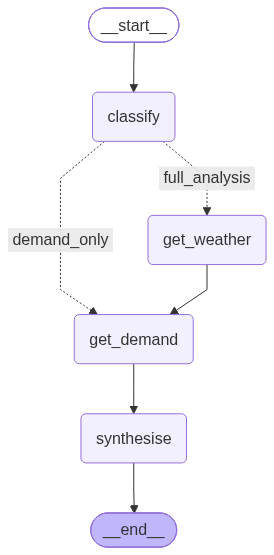

In [25]:
# Draw the workflow graph so the LangGraph control flow is visible.
if LG_AVAILABLE:
    from IPython.display import Image, display
    display(Image(lg_app.get_graph().draw_mermaid_png()))

## Section 4: Build vs Buy Rubric

Build vs Buy is the decision that precedes framework selection.
If the answer is Buy, you are evaluating vendors, not frameworks.

The rubric scores five axes (each 1-3):
- **Differentiation:** Does this component create competitive advantage?
- **Complexity:** How hard is it to build and maintain at scale?
- **Vendor risk:** How much lock-in does buying create?
- **Speed to value:** How fast does buy vs build deliver the first working version?
- **Cost advantage:** Is build cost (engineering time) lower or higher than buy cost (licensing + integration)?

Score >= 11 = **Build** | Score <= 8 = **Buy** | 9-10 = **Buy + Customize**

In [26]:
# Score each platform decision with the same simple rubric.
# This makes the Build vs Buy choice more explicit and repeatable.
def build_or_buy(component: str, scores: dict) -> dict:
    # scores: each axis is 1=Buy-favoured, 2=Neutral, 3=Build-favoured
    total = sum(scores.values())
    if total >= 11: # Higher score means stronger case for building. If the score is 11 or above, Walmart should build according to this rubric.
        decision  = 'BUILD'
        rationale = 'Component creates differentiation or vendor risk is too high to accept'
    elif total <= 8:
        decision  = 'BUY'
        rationale = 'Commodity capability; vendor delivers faster and cheaper'
    else:
        decision  = 'BUY + CUSTOMIZE'
        rationale = 'Start with vendor solution, extend where differentiation matters'
    return {
        'component': component, 'scores': scores,
        'total': total, 'decision': decision, 'rationale': rationale,
    }

components = [
    ('Orchestration framework (LangGraph)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 2,     'speed_advantage': 3, 'cost_advantage': 1,
    }),
    ('RAG vector store (Chroma vs Pinecone)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 1,     'speed_advantage': 1, 'cost_advantage': 2,
    }),
    ('Walmart domain knowledge base (Q&A dataset)', {
        'differentiation': 3, 'complexity': 1,
        'vendor_risk': 3,     'speed_advantage': 1, 'cost_advantage': 3,
    }),
    ('LLM inference (OpenAI API vs self-hosted)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 2,     'speed_advantage': 1, 'cost_advantage': 1,
    }),
    ('MCP tool server (FastMCP vs custom HTTP)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 1,     'speed_advantage': 3, 'cost_advantage': 2,
    }),
]

results = [build_or_buy(name, scores) for name, scores in components]

print(f'{"Component":<48} {"Score":>6} {"Decision":>18}')
print('-' * 74)
for r in results:
    print(f'{r["component"]:<48} {r["total"]:>6} {r["decision"]:>18}')

print()
for r in results:
    print(f'{r["component"]}:')
    print(f'  {r["decision"]}: {r["rationale"]}')

Component                                         Score           Decision
--------------------------------------------------------------------------
Orchestration framework (LangGraph)                   9    BUY + CUSTOMIZE
RAG vector store (Chroma vs Pinecone)                 8                BUY
Walmart domain knowledge base (Q&A dataset)          11              BUILD
LLM inference (OpenAI API vs self-hosted)             8                BUY
MCP tool server (FastMCP vs custom HTTP)              9    BUY + CUSTOMIZE

Orchestration framework (LangGraph):
  BUY + CUSTOMIZE: Start with vendor solution, extend where differentiation matters
RAG vector store (Chroma vs Pinecone):
  BUY: Commodity capability; vendor delivers faster and cheaper
Walmart domain knowledge base (Q&A dataset):
  BUILD: Component creates differentiation or vendor risk is too high to accept
LLM inference (OpenAI API vs self-hosted):
  BUY: Commodity capability; vendor delivers faster and cheaper
MCP tool server (F

In [27]:
# The key learning is:
#     Build what creates Walmart-specific competitive value. Buy commodity technology where vendors can deliver it faster and cheaper. Customize the middle layer where you need both speed and control.

## Summary

You have built and compared production-grade AI protocol and framework implementations using **live external data**:

- **Protocol:** REST vs MCP -- both called real OpenWeatherMap and Tavily APIs. MCP wins for multi-agent reuse at Walmart scale because tool schemas live on the server, not in every agent's code.
- **Framework:** All three frameworks fetched real weather and real demand signals and produced grounded recommendations from live data. LangGraph's explicit typed state is the right choice for the Walmart Retail Assistant's multi-step workflow.
- **Build vs Buy:** Quantified per component. Domain knowledge base is always BUILD. Everything else is BUY or BUY+CUSTOMIZE using open-source tools.

**Key principle:** These decisions compound. Wrong protocol forces a framework rewrite. Wrong Build vs Buy wastes 3-6 months of engineering. Score the rubric before writing a single line of production code.

**Your deliverable:** `framework_selection_matrix.txt` -- ARB-ready with live latency and cost data from this session.

**Next:** IN04 -- Agent Design Principles